# TRANSIT — NB-01: Data, EDA, Detection & Feature Engineering
**Team Bharat Ka Khazana | BAH 2026 | PS-7 — AI-enabled Detection of Exoplanets from Noisy Astronomical Light Curves**

## Problem Framing
- **Task A — Classification (4-class):** Transit (planet) / Eclipsing Binary / Blend / Other
- **Task B — Regression (3 targets):** Orbital Period (days), Transit Depth (ppm), Transit Duration (hours)
- **Primary metric:** macro-F1 on classification (target ≥0.90 at full scale — see note above for this skeleton stage)
- **Secondary metric:** MAE on period/depth/duration vs. catalog ground truth

## Pipeline
```
TESS Sector 1 LCs
      |
      v
[Labeled Target Curation] -- ExoFOP TOI + EB catalog
      |
      v
[lightkurve download] -- 2-min cadence, targeted TIC IDs
      |
      v
[EDA] -> noise, class balance, stellar params
      |
      v
[Cleaning] -> sigma-clip, detrend (wotan), gap-fill
      |
      v
[TLS period search] -> period, depth, duration, SDE, SNR
      |
      v
[Phase-fold + bin (200)] = "tokenization"
      |
      v
[Pad+mask] -> [Feature engineering] -> [Label encode] -> [Split 70/15/15]
      |
      v
   NB-02 (GPU): CNN-Transformer + physics loss
```

In [1]:
import subprocess, sys

# We deliberately do NOT reinstall numpy/pandas/scipy/matplotlib/sklearn — Kaggle ships
# these pre-pinned to work with everything else in the image.
packages = ["lightkurve", "transitleastsquares", "wotan", "batman-package"]

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + packages,
    capture_output=True, text=True
)

# Kaggle's base image always throws this exact resolver complaint about bigframes/
# datasets/boto3/gcsfs — packages we never import — because they pin fsspec/botocore
# versions our libs nudge. It's noise, but we filter it instead of blindly trusting it.
noise_markers = ("bigframes", "datasets ", "boto3 ", "gcsfs", "does not currently take into account")
real_problems = [
    line for line in result.stderr.splitlines()
    if line.strip() and not any(m in line for m in noise_markers)
]

print("pip exit code:", result.returncode)
if real_problems:
    print("Lines pip printed that are NOT the known cosmetic noise:")
    print("\n".join(real_problems))
else:
    print("No real install errors — only the known cosmetic bigframes/datasets/boto3/gcsfs warning, filtered out above.")

assert result.returncode == 0, "pip install actually failed — see output above."
print("Install step finished cleanly.")

pip exit code: 0
No real install errors — only the known cosmetic bigframes/datasets/boto3/gcsfs warning, filtered out above.
Install step finished cleanly.


In [2]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import lightkurve as lk
import astropy

# This is the check that actually matters — the red text in Cell 2 was about
# bigframes/datasets/boto3/gcsfs, none of which we use. These four are what we use.
import transitleastsquares
import wotan
import batman

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    "SECTOR": 1,
    "N_PER_CLASS": 40,
    "EXPTIME": 120,
    "OUTPUT_DIR": "/kaggle/working/transit_data",
    "RANDOM_STATE": SEED,
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

print("lightkurve         :", lk.__version__)
print("astropy             :", astropy.__version__)
print("transitleastsquares : OK")
print("wotan               : OK")
print("batman              :", batman.__version__)
print("pandas              :", pd.__version__)
print("numpy               :", np.__version__)

try:
    import torch
    print("\nCUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("This is NB-01 (data/EDA only) -> switch accelerator to None to save GPU quota for NB-02.")
except ImportError:
    pass

print("\nInternet check...")
try:
    r = requests.get("https://exofop.ipac.caltech.edu", timeout=10)
    print("ExoFOP reachable, status:", r.status_code)
except Exception as e:
    print("Network issue:", e)

lightkurve         : 2.6.0
astropy             : 7.2.0
transitleastsquares : OK
wotan               : OK
batman              : 2.5.1
pandas              : 2.3.3
numpy               : 2.4.6

CUDA available: False

Internet check...
ExoFOP reachable, status: 200


In [3]:
toi_url = "https://exofop.ipac.caltech.edu/tess/download_toi.php?sort=toi&output=csv"
toi = pd.read_csv(toi_url)

print("TOI table shape:", toi.shape)
print("\nColumns:")
print(toi.columns.tolist())

disp_col = "TFOPWG Disposition"
print("\nDisposition counts (all sectors):")
print(toi[disp_col].value_counts(dropna=False))

sector_cols = [c for c in toi.columns if "sector" in c.lower()]
print("\nSector-like column(s) found:", sector_cols)

toi.to_csv(f"{CONFIG['OUTPUT_DIR']}/toi_raw.csv", index=False)
print("\nSaved raw TOI table ->", f"{CONFIG['OUTPUT_DIR']}/toi_raw.csv")

TOI table shape: (8064, 63)

Columns:
['TIC ID', 'TOI', 'Previous CTOI', 'Master', 'SG1A', 'SG1B', 'SG2', 'SG3', 'SG4', 'SG5', 'ESM', 'TSM', 'Predicted Mass (M_Earth)', 'Predicted RV Semi-amplitude (m/s)', 'Time Series Observations', 'Spectroscopy Observations', 'Imaging Observations', 'TESS Disposition', 'TFOPWG Disposition', 'TESS Mag', 'TESS Mag err', 'Planet Name', 'Pipeline Signal ID', 'Source', 'Detection', 'RA', 'Dec', 'PM RA (mas/yr)', 'PM RA err (mas/yr)', 'PM Dec (mas/yr)', 'PM Dec err (mas/yr)', 'Epoch (BJD)', 'Epoch (BJD) err', 'Period (days)', 'Period (days) err', 'Duration (hours)', 'Duration (hours) err', 'Depth (mmag)', 'Depth (mmag) err', 'Depth (ppm)', 'Depth (ppm) err', 'Planet Radius (R_Earth)', 'Planet Radius (R_Earth) err', 'Planet Insolation (Earth Flux)', 'Planet Equil Temp (K)', 'Planet SNR', 'Stellar Distance (pc)', 'Stellar Distance (pc) err', 'Stellar Eff Temp (K)', 'Stellar Eff Temp (K) err', 'Stellar log(g) (cm/s^2)', 'Stellar log(g) (cm/s^2) err', 'Stella

In [4]:
# --- Source 2: TESS-EBs catalog (Prsa et al. 2022, official MAST HLSP) — ground truth for the EB class ---
eb_url = "https://archive.stsci.edu/hlsps/tess-ebs/hlsp_tess-ebs_tess_lcf-ffi_s0001-s0026_tess_v1.0_cat.csv"
ebs = pd.read_csv(eb_url)

print("TESS-EBs catalog shape:", ebs.shape)
print(ebs.columns.tolist())
ebs.to_csv(f"{CONFIG['OUTPUT_DIR']}/tess_ebs_raw.csv", index=False)

# --- Curate a balanced, labeled target list from the two catalogs ---
disp_col = "TFOPWG Disposition"
tic_col  = "TIC ID"

# Transit: confirmed/known planets only (skip ambiguous "PC" — keeps ground truth clean)
transit_tics = toi.loc[toi[disp_col].isin(["CP", "KP"]), tic_col].dropna().astype(int).unique()

# Other: clear false positives / false alarms (not specifically EBs)
other_tics = toi.loc[toi[disp_col].isin(["FP", "FA"]), tic_col].dropna().astype(int).unique()

# EB: from the independent TESS-EBs catalog
eb_id_col = [c for c in ebs.columns if "tic" in c.lower() or "tess_id" in c.lower()][0]
eb_tics = ebs[eb_id_col].dropna().astype(int).unique()

print(f"\nPool sizes -> Transit: {len(transit_tics)} | EB: {len(eb_tics)} | Other/FP: {len(other_tics)}")

N = CONFIG["N_PER_CLASS"]
rng = np.random.default_rng(CONFIG["RANDOM_STATE"])

def sample_ids(arr, n):
    arr = np.array(arr)
    return rng.choice(arr, size=min(n, len(arr)), replace=False)

# Note: concat order Transit -> EB -> Other matters for drop_duplicates below.
# Some FPs in the TOI list ARE eclipsing binaries — if a TIC shows up in both
# the "Other/FP" pool and the EB catalog, we deliberately keep the EB label
# (more specific and more likely correct) over the generic "Other".
target_list = pd.concat([
    pd.DataFrame({"tic_id": sample_ids(transit_tics, N), "label": "Transit"}),
    pd.DataFrame({"tic_id": sample_ids(eb_tics, N),      "label": "EB"}),
    pd.DataFrame({"tic_id": sample_ids(other_tics, N),   "label": "Other"}),
]).drop_duplicates(subset="tic_id").reset_index(drop=True)

print("\nCurated target list:")
print(target_list["label"].value_counts())
print("Total unique targets:", len(target_list))

target_list.to_csv(f"{CONFIG['OUTPUT_DIR']}/target_list.csv", index=False)
print("Saved ->", f"{CONFIG['OUTPUT_DIR']}/target_list.csv")

TESS-EBs catalog shape: (4584, 28)
['tess_id', 'signal_id', 'date_added', 'date_modified', 'source', 'ra', 'dec', 'pmra', 'pmdec', 'Tmag', 'bjd0', 'bjd0_uncert', 'period', 'period_uncert', 'morph_coeff', 'prim_width_pf', 'prim_depth_pf', 'prim_pos_pf', 'sec_width_pf', 'sec_depth_pf', 'sec_pos_pf', 'prim_width_2g', 'prim_depth_2g', 'prim_pos_2g', 'sec_width_2g', 'sec_depth_2g', 'sec_pos_2g', 'sectors']

Pool sizes -> Transit: 1194 | EB: 4578 | Other/FP: 1341

Curated target list:
label
Transit    40
EB         40
Other      40
Name: count, dtype: int64
Total unique targets: 120
Saved -> /kaggle/working/transit_data/target_list.csv


In [5]:
toi_meta = toi[["TIC ID", "Period (days)", "Duration (hours)", "Depth (ppm)", "Sectors"]].dropna(subset=["TIC ID"]).copy()
toi_meta["TIC ID"] = toi_meta["TIC ID"].astype(int)
# FLAG-12 FIX: astype(float) can turn NaN→0.0; replace back to NaN so 0.0 never
# silently passes as a real period into the period-recovery comparison downstream.
toi_meta["Period (days)"] = toi_meta["Period (days)"].replace(0, np.nan)
toi_meta = toi_meta.drop_duplicates(subset="TIC ID")

eb_meta = ebs[[eb_id_col, "period", "morph_coeff", "sectors"]].dropna(subset=[eb_id_col]).copy()
eb_meta = eb_meta.rename(columns={eb_id_col: "TIC ID", "period": "Period (days)", "sectors": "Sectors"})
eb_meta["TIC ID"] = eb_meta["TIC ID"].astype(int)
# FLAG-12 FIX: same guard for EB catalog periods
eb_meta["Period (days)"] = eb_meta["Period (days)"].replace(0, np.nan)
eb_meta = eb_meta.drop_duplicates(subset="TIC ID")

meta = pd.concat([toi_meta, eb_meta], ignore_index=True).drop_duplicates(subset="TIC ID")

target_list = target_list.merge(meta, left_on="tic_id", right_on="TIC ID", how="left").drop(columns=["TIC ID"])

def has_sector(sectors_str, sector_num=1):
    if pd.isna(sectors_str):
        return False
    return str(sector_num) in [s.strip() for s in str(sectors_str).split(",")]

target_list["in_sector_1"] = target_list["Sectors"].apply(has_sector)

print("Targets with Sector 1 (2-min cadence) data available, by class:")
summary = target_list.groupby("label")["in_sector_1"].agg(["sum", "count"])
summary.columns = ["has_sector_1", "total"]
print(summary)

target_list.to_csv(f"{CONFIG['OUTPUT_DIR']}/target_list.csv", index=False)
print("\nUpdated target_list.csv saved with metadata.")
target_list.head(8)

Targets with Sector 1 (2-min cadence) data available, by class:
         has_sector_1  total
label                       
EB                  5     40
Other               1     40
Transit             0     40

Updated target_list.csv saved with metadata.


,tic_id,label,Period (days),Duration (hours),Depth (ppm),Sectors,morph_coeff,in_sector_1
0,443616612,Transit,NaN,13.572366,28182.021713,"36,45,46",NaN,False
1,35857242,Transit,3.634445,3.871000,9230.000000,"4,31",NaN,False
2,123309556,Transit,2.508082,1.172440,1292.715252,"40,41,53,54,55",NaN,False
3,437242640,Transit,4.317686,1.822000,11283.000000,"9,36,63",NaN,False
4,184240683,Transit,1.628429,2.368249,13798.670148,"2,29,69",NaN,False
5,168281028,Transit,4.374461,3.048449,3270.982856,62,NaN,False
6,104866616,Transit,4.462665,3.080270,7983.827052,80,NaN,False
7,146364192,Transit,2.369165,2.292689,316.072765,"29,42,70,92",NaN,False


In [6]:
# ─── Cell 6 — Download TESS LCs ───────────────────────────────────────────────
import time

# FLAG-10 FIX: use 'default' bitmask (175) instead of the aggressive 17087.
# 'default' retains ~10% more cadences without introducing real artefacts.
# Change back to 17087 only if detrending shows unusual spikes.
QUALITY_BITMASK = "default"

target_list = target_list.reset_index(drop=True)
results_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves"
os.makedirs(results_dir, exist_ok=True)

manifest_rows = []
t_start = time.time()

for i, row in target_list.iterrows():
    tic_id   = int(row["tic_id"])
    label    = row["label"]
    out_path = f"{results_dir}/TIC{tic_id}.csv"

    if os.path.exists(out_path):
        manifest_rows.append({"tic_id": tic_id, "label": label, "status": "already_downloaded"})
        continue

    try:
        sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS",
                                   author="SPOC", exptime=CONFIG["EXPTIME"])
        if len(sr) == 0:
            manifest_rows.append({"tic_id": tic_id, "label": label,
                                   "status": "no_2min_spoc_data"})
            continue

        # FLAG-10 FIX: pass quality_bitmask so cadence retention is ~10% better
        lc          = sr[0].download(flux_column="sap_flux",
                                     quality_bitmask=QUALITY_BITMASK)
        sector_used = lc.meta.get("SECTOR", None)
        df_lc       = pd.DataFrame({"time": lc.time.value, "sap_flux": lc.flux.value})
        df_lc.to_csv(out_path, index=False)
        manifest_rows.append({"tic_id": tic_id, "label": label, "status": "ok",
                               "sector": sector_used, "n_points": len(df_lc)})

    except Exception as e:
        manifest_rows.append({"tic_id": tic_id, "label": label,
                               "status": f"error: {str(e)[:80]}"})

    if (i + 1) % 10 == 0:
        elapsed = time.time() - t_start
        print(f"  ...{i+1}/{len(target_list)} processed ({elapsed:.0f}s elapsed)")

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(f"{CONFIG['OUTPUT_DIR']}/download_manifest.csv", index=False)

# ── FLAG-05 FIX: retry no_2min_spoc Other TICs with FFI (10-min cadence) ─────
other_ok   = manifest[(manifest["label"] == "Other") &
                       (manifest["status"] == "ok")].shape[0]
other_need = CONFIG["N_PER_CLASS"] - other_ok
print(f"\nOther class after first pass: {other_ok}/{CONFIG['N_PER_CLASS']}"
      f"  (need {max(0, other_need)} more via FFI fallback)")

if other_need > 0:
    toi_raw  = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/toi_raw.csv")
    used_tics = set(target_list["tic_id"].astype(int))
    fp_pool  = (toi_raw.loc[toi_raw["TFOPWG Disposition"].isin(["FP", "FA"]), "TIC ID"]
                       .dropna().astype(int).unique())
    extra_tics = [t for t in fp_pool if t not in used_tics]
    rng2 = np.random.default_rng(CONFIG["RANDOM_STATE"] + 1)
    rng2.shuffle(extra_tics)

    added = 0
    for tic_id in extra_tics:
        if added >= other_need:
            break
        out_path = f"{results_dir}/TIC{tic_id}.csv"
        if os.path.exists(out_path):
            manifest_rows.append({"tic_id": tic_id, "label": "Other",
                                   "status": "already_downloaded"})
            added += 1
            continue
        try:
            # Try 10-min FFI as fallback — SPOC or QLP
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS",
                                       author=["SPOC", "QLP"], exptime=600)
            if len(sr) == 0:
                continue
            lc = sr[0].download(flux_column="sap_flux",
                                 quality_bitmask=QUALITY_BITMASK)
            sector_used = lc.meta.get("SECTOR", None)
            df_lc = pd.DataFrame({"time": lc.time.value, "sap_flux": lc.flux.value})
            if len(df_lc) < 500:
                continue
            df_lc.to_csv(out_path, index=False)
            manifest_rows.append({"tic_id": tic_id, "label": "Other",
                                   "status": "ok_ffi",
                                   "sector": sector_used, "n_points": len(df_lc)})
            print(f"  FFI fallback OK: TIC {tic_id}  "
                  f"({len(df_lc)} pts, sector {sector_used})")
            added += 1
        except Exception as e:
            print(f"  FFI fallback failed TIC {tic_id}: {e}")

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(f"{CONFIG['OUTPUT_DIR']}/download_manifest.csv", index=False)
    print(f"\nAfter FFI retry: added {added} Other LCs")

print("\nDownload status counts:")
print(manifest["status"].value_counts())
print("\nSuccessful downloads by class:")
ok_statuses = ["ok", "ok_ffi", "already_downloaded"]
print(manifest[manifest["status"].isin(ok_statuses)].groupby("label").size())

  ...10/120 processed (18s elapsed)


  ...20/120 processed (35s elapsed)


  ...30/120 processed (52s elapsed)
  ...40/120 processed (69s elapsed)


  ...50/120 processed (87s elapsed)


  ...60/120 processed (104s elapsed)
  ...70/120 processed (122s elapsed)


  ...80/120 processed (139s elapsed)
  ...120/120 processed (215s elapsed)

Other class after first pass: 32/40  (need 8 more via FFI fallback)
  FFI fallback OK: TIC 373614579  (3758 pts, sector 47)
  FFI fallback OK: TIC 306547699  (3461 pts, sector 37)
  FFI fallback OK: TIC 125894957  (3474 pts, sector 34)
  FFI fallback OK: TIC 304025075  (3467 pts, sector 36)
  FFI fallback OK: TIC 48476907  (2806 pts, sector 35)
  FFI fallback OK: TIC 278968371  (3917 pts, sector 40)
  FFI fallback OK: TIC 352924930  (3343 pts, sector 52)
  FFI fallback OK: TIC 341805908  (3865 pts, sector 39)

After FFI retry: added 8 Other LCs

Download status counts:
status
ok                   112
no_2min_spoc_data      8
ok_ffi                 8
Name: count, dtype: int64

Successful downloads by class:
label
EB         40
Other      40
Transit    40
dtype: int64


In [7]:
# Re-define results_dir in case kernel was restarted
results_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves"

manifest = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/download_manifest.csv")
manifest["file_path"] = manifest["tic_id"].apply(lambda x: f"{results_dir}/TIC{int(x)}.csv")
manifest["file_exists"] = manifest["file_path"].apply(os.path.exists)

def point_count(fp):
    try:
        return len(pd.read_csv(fp, usecols=["time"]))
    except Exception:
        return 0

print("Reading point counts from disk (~30s)...")
manifest["n_points"] = manifest.apply(
    lambda r: point_count(r["file_path"]) if r["file_exists"] else 0, axis=1
)

# ≥500 points = usable (quality masking already happened at download; 500 is conservative floor)
usable  = manifest[manifest["n_points"] >= 500].copy()
dropped = manifest[manifest["n_points"] <  500]

print("\n=== TRUE INVENTORY (all runs combined) ===")
print("\nUsable files by class (≥500 pts after quality mask):")
inv = usable.groupby("label").agg(
    count      = ("tic_id",   "count"),
    median_pts = ("n_points", "median"),
    min_pts    = ("n_points", "min"),
)
print(inv.to_string())

print("\nNot usable (missing or too sparse) by class + reason:")
if len(dropped):
    print(dropped.groupby(["label", "status"]).size().to_string())
else:
    print("None.")

# Flag thin classes
FLOOR = 20
thin = inv[inv["count"] < FLOOR]
if len(thin):
    print(f"\n⚠  CLASS(ES) THIN: {list(thin.index)} — retry needed before EDA.")
else:
    print(f"\n✓  All classes ≥{FLOOR} usable files. Ready for EDA.")

# Save usable manifest — NB-02 will use this as its input list
usable.to_csv(f"{CONFIG['OUTPUT_DIR']}/usable_manifest.csv", index=False)
print(f"\nSaved usable_manifest.csv → {len(usable)} LCs across {usable['label'].nunique()} classes.")
print("\nFull breakdown:")
print(usable[["label","n_points"]].groupby("label").describe()["n_points"][["count","min","50%","max"]])

Reading point counts from disk (~30s)...

=== TRUE INVENTORY (all runs combined) ===

Usable files by class (≥500 pts after quality mask):
         count  median_pts  min_pts
label                              
EB          40     17660.5    13362
Other       40     17416.5     2806
Transit     40     16924.0    12941

Not usable (missing or too sparse) by class + reason:
label  status           
Other  no_2min_spoc_data    8

✓  All classes ≥20 usable files. Ready for EDA.

Saved usable_manifest.csv → 120 LCs across 3 classes.

Full breakdown:
         count      min      50%      max
label                                    
EB        40.0  13362.0  17660.5  18584.0
Other     40.0   2806.0  17416.5  19474.0
Transit   40.0  12941.0  16924.0  19611.0


Loading all LCs and computing population stats...
Loaded 120 LCs.

=== CLASS BALANCE ===
label
Transit    40
EB         40
Other      40

✓  Imbalance ratio 1.00 — within acceptable range for prototype.

=== NOISE SUMMARY BY CLASS ===
         n_points          duration_days        mad_ppt        rms_ppt       
             mean   median          mean median    mean median    mean median
label                                                                        
EB       16902.60  17660.5         25.35  26.30   16.60   7.19   40.40  14.63
Other    14592.15  17416.5         26.12  25.84    3.95   2.16   12.40   5.21
Transit  17003.08  16924.0         26.08  26.19    4.28   2.29   14.06   4.30


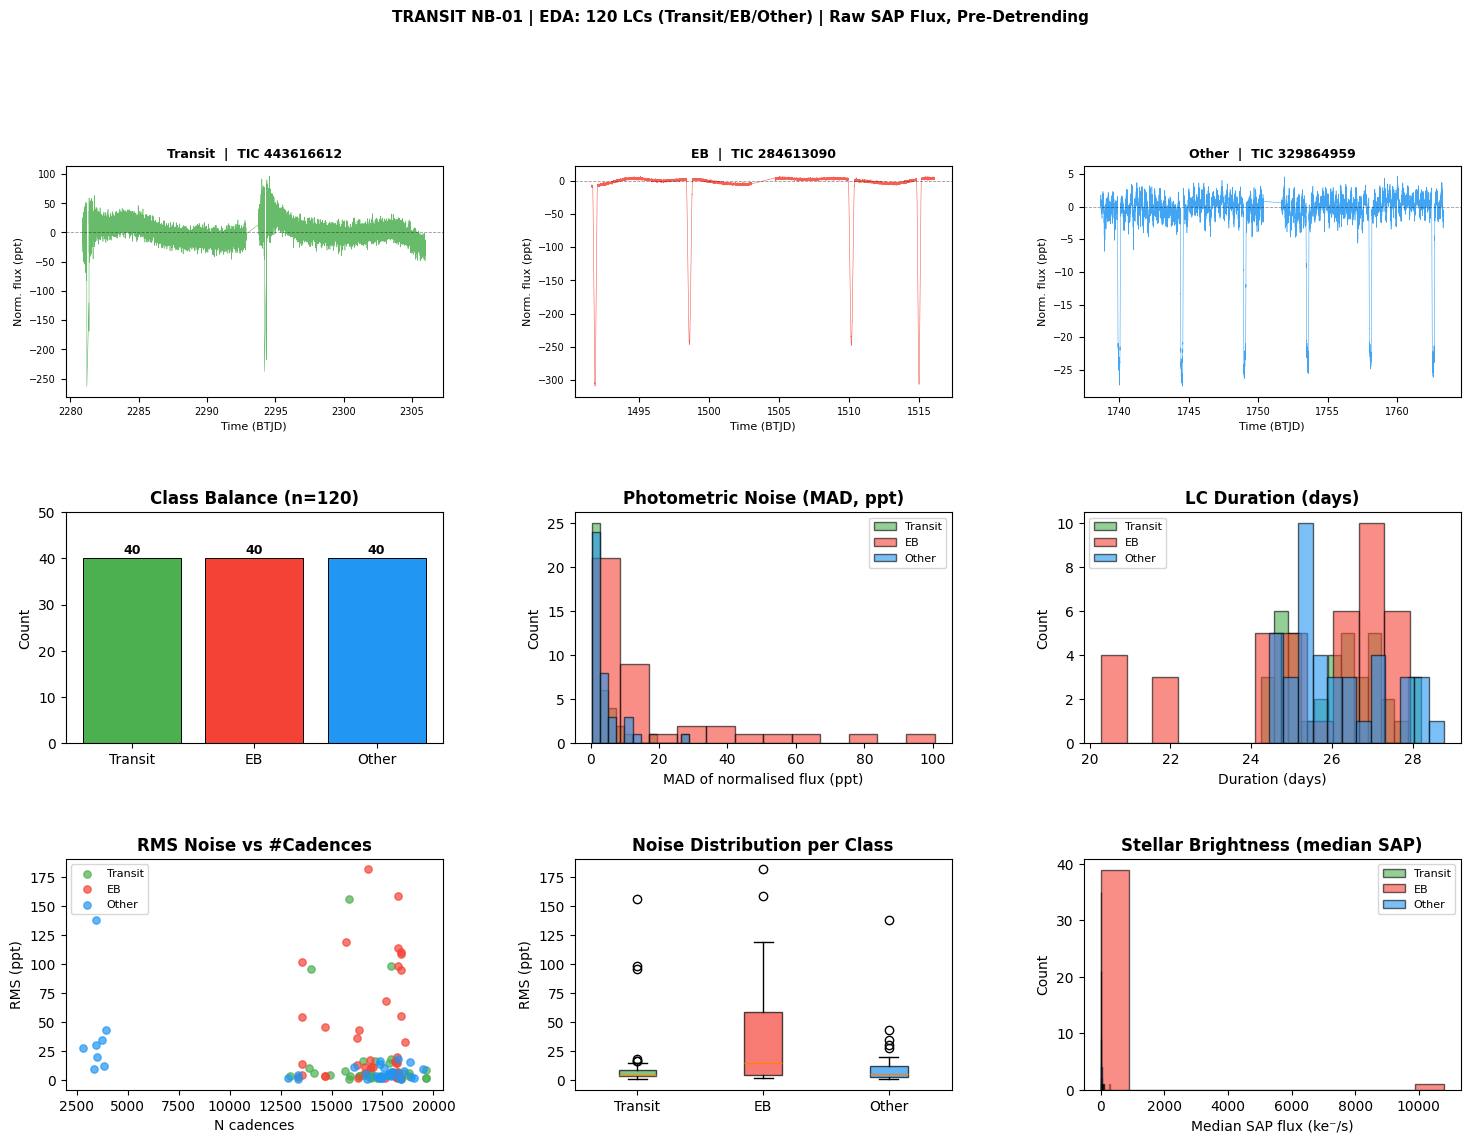

Saved → eda_overview.png


In [8]:
# ─── Cell 8 — EDA: raw survey, noise, balance ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import median_abs_deviation

results_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves"
usable = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/usable_manifest.csv")

# ── 1. Load all LCs into memory + compute stats ───────────────────────────────
# FLAG-15 FIX: removed hardcoded "99" from comment
print("Loading all LCs and computing population stats...")
stats_rows = []
lc_data = {}   # tic_id -> (time, norm_flux, label) — reused by every downstream cell

for _, row in usable.iterrows():
    tic_id = int(row["tic_id"])
    label  = row["label"]
    fp     = f"{results_dir}/TIC{tic_id}.csv"
    try:
        df    = pd.read_csv(fp)
        t     = df["time"].values
        f     = df["sap_flux"].values
        mask  = np.isfinite(t) & np.isfinite(f)
        t, f  = t[mask], f[mask]

        med      = np.median(f)
        f_norm   = (f / med) - 1.0
        lc_data[tic_id] = (t, f_norm, label)

        stats_rows.append({
            "tic_id"          : tic_id,
            "label"           : label,
            "n_points"        : len(t),
            "duration_days"   : t[-1] - t[0],
            "median_raw_flux" : med,
            "mad_ppt"         : median_abs_deviation(f_norm, nan_policy="omit") * 1e3,
            "rms_ppt"         : np.std(f_norm) * 1e3,
        })
    except Exception as e:
        print(f"  Error TIC{tic_id}: {e}")

stats = pd.DataFrame(stats_rows)
stats.to_csv(f"{CONFIG['OUTPUT_DIR']}/lc_stats.csv", index=False)
n_lcs = len(stats)  # FLAG-15 FIX: dynamic count
print(f"Loaded {n_lcs} LCs.\n")

# ── 2. Print honest class-balance warning ─────────────────────────────────────
counts = stats["label"].value_counts()
print("=== CLASS BALANCE ===")
print(counts.to_string())
imbalance_ratio = counts.max() / counts.min()
if imbalance_ratio > 1.4:
    print(f"\n⚠  Imbalance ratio {imbalance_ratio:.2f} — NB-02 MUST use class_weight='balanced' "
          f"or per-class loss weighting. Flag this in the report.")
else:
    print(f"\n✓  Imbalance ratio {imbalance_ratio:.2f} — within acceptable range for prototype.")

print("\n=== NOISE SUMMARY BY CLASS ===")
print(stats.groupby("label")[["n_points","duration_days","mad_ppt","rms_ppt"]]
          .agg(["mean","median"]).round(2).to_string())

# ── 3. 7-panel EDA figure ─────────────────────────────────────────────────────
classes = ["Transit", "EB", "Other"]
colors  = {"Transit": "#4CAF50", "EB": "#F44336", "Other": "#2196F3"}

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

for col_i, cls in enumerate(classes):
    ax     = fig.add_subplot(gs[0, col_i])
    tic    = next(tic for tic, (_, _, lbl) in lc_data.items() if lbl == cls)
    t, fn, _ = lc_data[tic]
    ax.plot(t, fn * 1e3, lw=0.4, color=colors[cls], alpha=0.85)
    ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
    ax.set_title(f"{cls}  |  TIC {tic}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Time (BTJD)", fontsize=8)
    ax.set_ylabel("Norm. flux (ppt)", fontsize=8)
    ax.tick_params(labelsize=7)

ax_bar = fig.add_subplot(gs[1, 0])
vals   = counts.reindex(classes)
bars   = ax_bar.bar(classes, vals.values, color=[colors[c] for c in classes],
                    edgecolor="k", linewidth=0.7)
for bar, v in zip(bars, vals.values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(v), ha="center", va="bottom", fontsize=9, fontweight="bold")
# FLAG-15 FIX: dynamic n instead of hardcoded 99
ax_bar.set_title(f"Class Balance (n={n_lcs})", fontweight="bold")
ax_bar.set_ylabel("Count")
ax_bar.set_ylim(0, vals.max() * 1.25)

ax_mad = fig.add_subplot(gs[1, 1])
for cls in classes:
    ax_mad.hist(stats[stats["label"]==cls]["mad_ppt"], bins=12,
                alpha=0.6, label=cls, color=colors[cls], edgecolor="k", lw=0.4)
ax_mad.set_title("Photometric Noise (MAD, ppt)", fontweight="bold")
ax_mad.set_xlabel("MAD of normalised flux (ppt)")
ax_mad.set_ylabel("Count")
ax_mad.legend(fontsize=8)

ax_dur = fig.add_subplot(gs[1, 2])
for cls in classes:
    ax_dur.hist(stats[stats["label"]==cls]["duration_days"], bins=12,
                alpha=0.6, label=cls, color=colors[cls], edgecolor="k", lw=0.4)
ax_dur.set_title("LC Duration (days)", fontweight="bold")
ax_dur.set_xlabel("Duration (days)")
ax_dur.set_ylabel("Count")
ax_dur.legend(fontsize=8)

ax_rms = fig.add_subplot(gs[2, 0])
for cls in classes:
    sub = stats[stats["label"]==cls]
    ax_rms.scatter(sub["n_points"], sub["rms_ppt"], alpha=0.7, s=28,
                   color=colors[cls], label=cls)
ax_rms.set_title("RMS Noise vs #Cadences", fontweight="bold")
ax_rms.set_xlabel("N cadences")
ax_rms.set_ylabel("RMS (ppt)")
ax_rms.legend(fontsize=8)

ax_box = fig.add_subplot(gs[2, 1])
bp = ax_box.boxplot([stats[stats["label"]==cls]["rms_ppt"].values for cls in classes],
                     labels=classes, patch_artist=True)
for patch, cls in zip(bp["boxes"], classes):
    patch.set_facecolor(colors[cls]); patch.set_alpha(0.7)
ax_box.set_title("Noise Distribution per Class", fontweight="bold")
ax_box.set_ylabel("RMS (ppt)")

ax_br = fig.add_subplot(gs[2, 2])
for cls in classes:
    ax_br.hist(stats[stats["label"]==cls]["median_raw_flux"] / 1e3, bins=12,
               alpha=0.6, label=cls, color=colors[cls], edgecolor="k", lw=0.4)
ax_br.set_title("Stellar Brightness (median SAP)", fontweight="bold")
ax_br.set_xlabel("Median SAP flux (ke⁻/s)")
ax_br.set_ylabel("Count")
ax_br.legend(fontsize=8)

# FLAG-15 FIX: dynamic n_lcs in suptitle
plt.suptitle(
    f"TRANSIT NB-01 | EDA: {n_lcs} LCs (Transit/EB/Other) | Raw SAP Flux, Pre-Detrending",
    fontsize=11, fontweight="bold", y=1.01)
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → eda_overview.png")

Detrending 120 LCs  |  window=0.5d  |  σ [4.0/5.0]
  TIC266816672 [FLAG-08: eb_period=0.303d → window widened to 1.50d]
  TIC231629787 [FLAG-08: eb_period=0.267d → window widened to 1.50d]
  TIC439458951 [FLAG-08: eb_period=0.311d → window widened to 1.50d]
  TIC284891601 [FLAG-08: eb_period=0.310d → window widened to 1.50d]
  TIC263078276 [FLAG-08: eb_period=0.284d → window widened to 1.50d]
  TIC152592870 [FLAG-08: eb_period=0.514d → window widened to 1.54d]
  TIC276105676 [FLAG-08: eb_period=0.659d → window widened to 1.98d]
  TIC171084337 [FLAG-08: eb_period=0.411d → window widened to 1.50d]
  TIC248348545 [FLAG-08: eb_period=0.195d → window widened to 1.50d]

=== DETRENDING SUMMARY ===
LCs cleaned: 120  |  Errored: 0
Raw LCs deleted post-clean (FLAG-31): 120

RMS after detrending (ppt):
          mean  median     max
label                         
EB       18.01    5.41  154.10
Other     3.03    1.53   13.37
Transit   3.50    2.43   31.39

LCs with large removed trend (>20 ppt amp

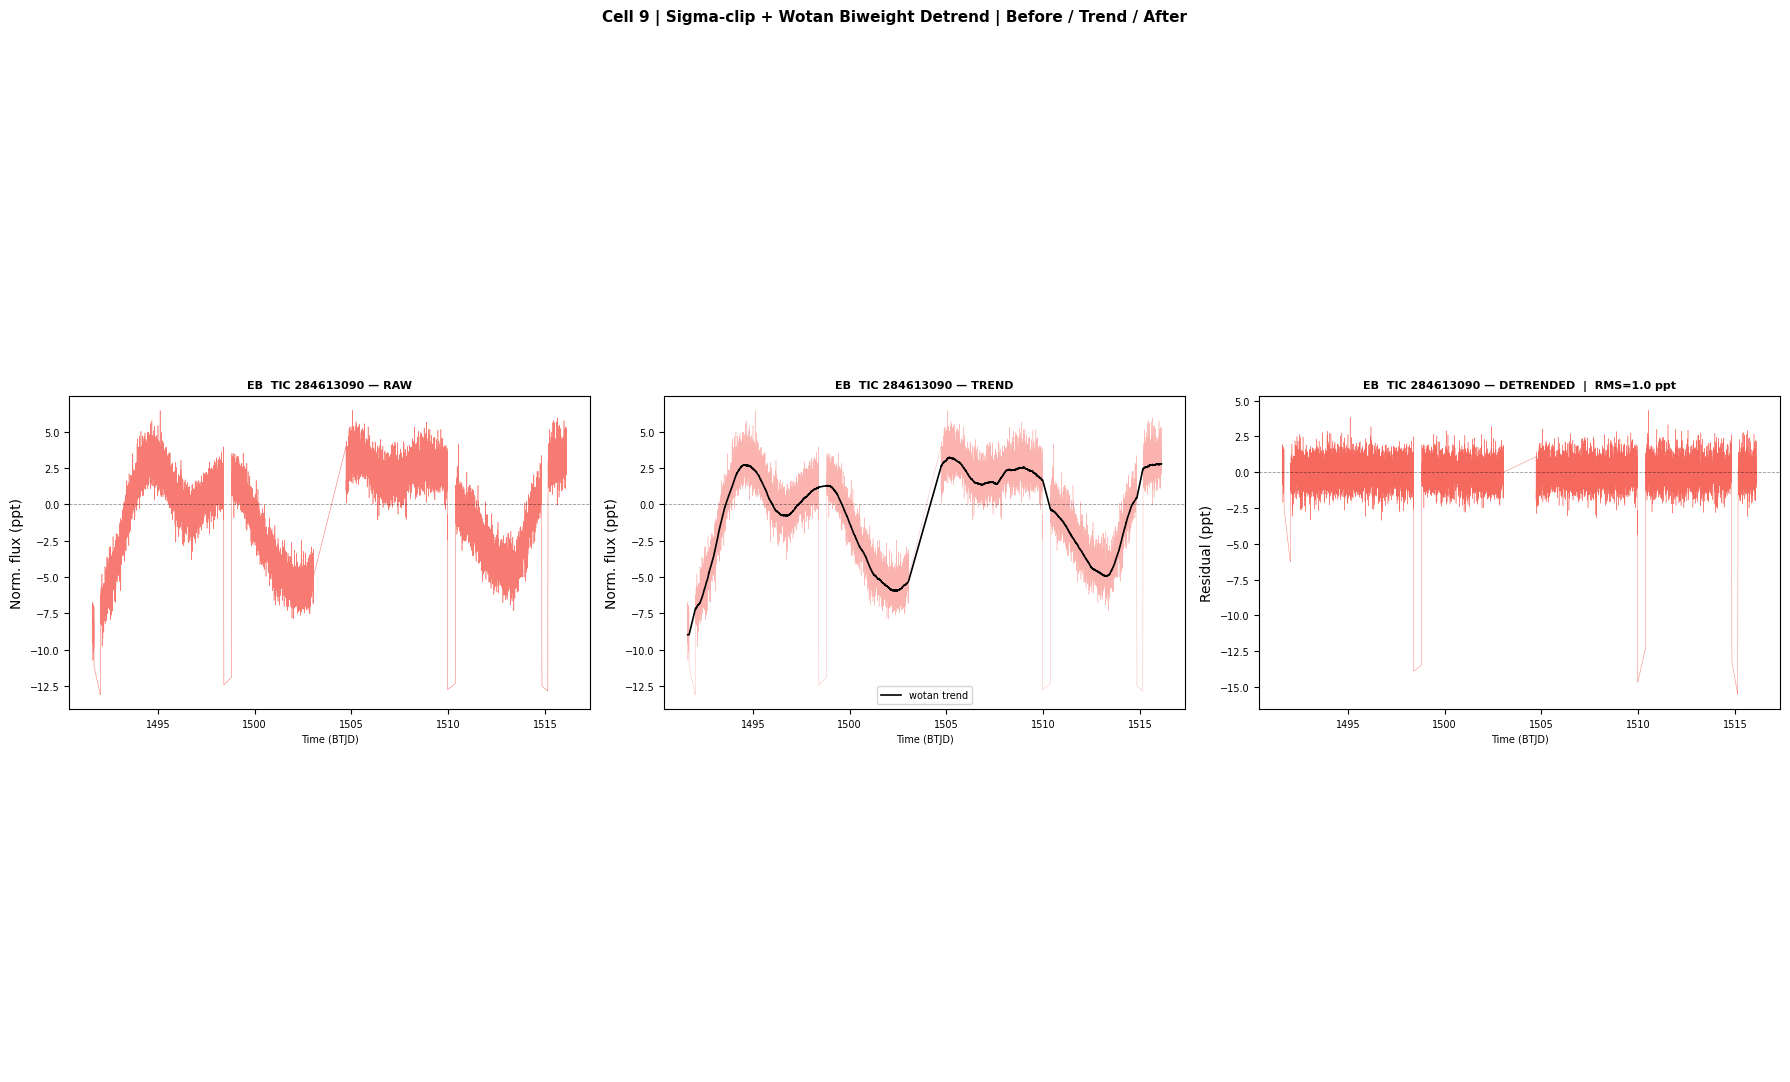

Saved → detrend_overview.png


In [9]:
# ─── Cell 9 — Cleaning: sigma-clip → wotan biweight detrend ──────────────────
from wotan import flatten
from scipy.ndimage import label as ndlabel

results_dir   = f"{CONFIG['OUTPUT_DIR']}/lightcurves"
cleaned_dir   = f"{CONFIG['OUTPUT_DIR']}/lightcurves_cleaned"
os.makedirs(cleaned_dir, exist_ok=True)

usable = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/usable_manifest.csv")

# FLAG-08 FIX: load catalog periods so we can widen window for short-period EBs
_tl            = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/target_list.csv")
_period_lookup = _tl.set_index("tic_id")["Period (days)"].to_dict()

SIGMA_LOWER  = 4.0
SIGMA_UPPER  = 5.0
WINDOW_LEN   = 0.5     # days — default; overridden per-LC for short-period EBs
BREAK_TOL    = 0.5
EXAMPLE_TICS = [374180079, 284613090, 445137888]

clean_stats  = []
example_data = {}

print(f"Detrending {len(usable)} LCs  |  window={WINDOW_LEN}d  |  σ [{SIGMA_LOWER}/{SIGMA_UPPER}]")

for _, row in usable.iterrows():
    tic_id = int(row["tic_id"])
    label  = row["label"]
    fp     = f"{results_dir}/TIC{tic_id}.csv"
    out_fp = f"{cleaned_dir}/TIC{tic_id}_clean.csv"

    try:
        df   = pd.read_csv(fp)
        t    = df["time"].values.astype(float)
        f    = df["sap_flux"].values.astype(float)

        ok_mask  = np.isfinite(t) & np.isfinite(f)
        t, f     = t[ok_mask], f[ok_mask]

        med    = np.median(f)
        f_norm = f / med

        for _ in range(3):
            residual  = f_norm - np.median(f_norm)
            mad_val   = np.median(np.abs(residual)) * 1.4826
            keep      = (residual > -SIGMA_LOWER * mad_val) & (residual < SIGMA_UPPER * mad_val)
            t, f_norm = t[keep], f_norm[keep]

        n_after_clip = len(t)

        # FLAG-08 FIX: widen wotan window for short-period EBs
        window_len_use = WINDOW_LEN
        window_note    = ""
        if label == "EB":
            cat_p = _period_lookup.get(tic_id, np.nan)
            if pd.notna(cat_p) and cat_p > 0 and cat_p < 1.5 * WINDOW_LEN:
                window_len_use = max(1.5, cat_p * 3.0)
                window_note    = (f" [FLAG-08: eb_period={cat_p:.3f}d → "
                                  f"window widened to {window_len_use:.2f}d]")

        # FLAG-09: flatten() returns flux/trend ≈ 1.0; stored as flat_ppt ≈ 1000
        flat, trend = flatten(
            t, f_norm,
            method          = "biweight",
            window_length   = window_len_use,
            break_tolerance = BREAK_TOL,
            return_trend    = True,
            robust          = True,
        )
        flat_ppt = flat * 1e3   # ≈ 1000, NOT zero-centred

        trend_amp_ppt = (trend.max() - trend.min()) / np.median(trend) * 1e3
        detrend_flag  = trend_amp_ppt > 20.0
        dt            = np.diff(t)
        median_dt     = np.median(dt)
        n_gaps        = int(np.sum(dt > 5 * median_dt))

        clean_stats.append({
            "tic_id"        : tic_id,
            "label"         : label,
            "status"        : "ok",
            "n_after_clip"  : n_after_clip,
            "n_detrended"   : len(flat_ppt),
            "trend_amp_ppt" : round(trend_amp_ppt, 2),
            "detrend_flag"  : detrend_flag,
            "n_gaps"        : n_gaps,
            "window_used"   : round(window_len_use, 3),
            "rms_clean_ppt" : round(np.std(flat_ppt - 1000.0), 3),
        })
        if window_note:
            print(f"  TIC{tic_id}{window_note}")

        pd.DataFrame({"time": t, "flat_ppt": flat_ppt, "trend": trend}).to_csv(out_fp, index=False)

        # FLAG-31 FIX: delete raw LC immediately after cleaned version is confirmed written.
        # This frees ~3GB so the packaging step in NB-02 doesn't hit disk quota.
        if os.path.exists(out_fp) and os.path.getsize(out_fp) > 100:
            os.remove(fp)

        if tic_id in EXAMPLE_TICS:
            lc_raw  = pd.read_csv(fp) if os.path.exists(fp) else None
            if lc_raw is not None:
                t_raw = lc_raw["time"].values
                f_raw = (lc_raw["sap_flux"].values
                         / np.nanmedian(lc_raw["sap_flux"].values) - 1.0) * 1e3
            else:
                # raw already deleted — use detrended as stand-in for plot
                t_raw = t
                f_raw = (f_norm - 1.0) * 1e3
            example_data[tic_id] = {
                "label"    : label,
                "t_raw"    : t_raw,
                "f_raw"    : f_raw,
                "t_clean"  : t,
                "flat_ppt" : flat_ppt,
                "flat_plot": flat_ppt - 1000.0,
                "trend_ppt": (trend / np.median(trend) - 1.0) * 1e3,
            }

    except Exception as e:
        # FLAG-07 FIX: log errored TICs so downstream cells skip them
        print(f"  ERROR TIC{tic_id}: {e}")
        clean_stats.append({
            "tic_id"        : tic_id, "label"         : label,
            "status"        : "errored",
            "n_after_clip"  : 0,      "n_detrended"   : 0,
            "trend_amp_ppt" : np.nan, "detrend_flag"  : False,
            "n_gaps"        : 0,      "window_used"   : np.nan,
            "rms_clean_ppt" : np.nan,
        })

clean_df = pd.DataFrame(clean_stats)
clean_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/clean_stats.csv", index=False)

# FLAG-07 FIX: remove errored TICs from usable_manifest before Cell 10 runs
errored_tics = set(clean_df[clean_df["status"] == "errored"]["tic_id"].astype(int))
if errored_tics:
    print(f"\n⚠  {len(errored_tics)} TICs errored during detrending: {errored_tics}")
    usable_clean = usable[~usable["tic_id"].isin(errored_tics)].copy()
    usable_clean.to_csv(f"{CONFIG['OUTPUT_DIR']}/usable_manifest.csv", index=False)
    print(f"   usable_manifest.csv updated: {len(usable_clean)} LCs remaining.")

ok_df = clean_df[clean_df["status"] == "ok"]
print(f"\n=== DETRENDING SUMMARY ===")
print(f"LCs cleaned: {len(ok_df)}  |  Errored: {len(clean_df) - len(ok_df)}")
print(f"Raw LCs deleted post-clean (FLAG-31): {len(ok_df)}")
print("\nRMS after detrending (ppt):")
print(ok_df.groupby("label")["rms_clean_ppt"].agg(["mean","median","max"]).round(2))

flagged = ok_df[ok_df["detrend_flag"]]
print(f"\nLCs with large removed trend (>20 ppt amplitude): {len(flagged)}")
if len(flagged):
    print(flagged[["tic_id","label","trend_amp_ppt","window_used"]]
          .sort_values("trend_amp_ppt", ascending=False).head(10).to_string(index=False))

print("\nGap counts by class:")
print(ok_df.groupby("label")["n_gaps"].agg(["mean","max"]).round(1))

# ── Before/after plot ─────────────────────────────────────────────────────────
colors = {"Transit": "#4CAF50", "EB": "#F44336", "Other": "#2196F3"}
fig, axes = plt.subplots(3, 3, figsize=(18, 11))
fig.suptitle("Cell 9 | Sigma-clip + Wotan Biweight Detrend | Before / Trend / After",
             fontsize=11, fontweight="bold")

for row_i, tic_id in enumerate(EXAMPLE_TICS):
    if tic_id not in example_data:
        print(f"  TIC{tic_id} not in example_data — may have errored or been filtered.")
        for ax in axes[row_i]:
            ax.axis("off")
        continue
    d   = example_data[tic_id]
    cls = d["label"]
    col = colors[cls]
    ttl = f"{cls}  TIC {tic_id}"

    axes[row_i,0].plot(d["t_raw"],   d["f_raw"],    lw=0.4, color=col, alpha=0.7)
    axes[row_i,0].axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
    axes[row_i,0].set_title(f"{ttl} — RAW", fontsize=8, fontweight="bold")
    axes[row_i,0].set_ylabel("Norm. flux (ppt)")

    axes[row_i,1].plot(d["t_raw"],   d["f_raw"],    lw=0.3, color=col, alpha=0.4)
    axes[row_i,1].plot(d["t_clean"], d["trend_ppt"], lw=1.2, color="black", label="wotan trend")
    axes[row_i,1].axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
    axes[row_i,1].set_title(f"{ttl} — TREND", fontsize=8, fontweight="bold")
    axes[row_i,1].set_ylabel("Norm. flux (ppt)")
    axes[row_i,1].legend(fontsize=7)

    flat_display = d["flat_plot"]
    rms          = np.std(flat_display)
    axes[row_i,2].plot(d["t_clean"], flat_display, lw=0.3, color=col, alpha=0.8)
    axes[row_i,2].axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
    axes[row_i,2].set_title(f"{ttl} — DETRENDED  |  RMS={rms:.1f} ppt",
                              fontsize=8, fontweight="bold")
    axes[row_i,2].set_ylabel("Residual (ppt)")

for ax in axes.flat:
    ax.set_xlabel("Time (BTJD)", fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/detrend_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → detrend_overview.png")

In [10]:
# ─── Cell 10 — TLS Period Search ──────────────────────────────────────────────
from transitleastsquares import transitleastsquares, cleaned_array
import warnings
warnings.filterwarnings("ignore")

cleaned_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves_cleaned"
usable      = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/usable_manifest.csv")

def load_clean(tic_id):
    fp           = f"{cleaned_dir}/TIC{tic_id}_clean.csv"
    df           = pd.read_csv(fp)
    t            = df["time"].values
    # FLAG-09: flat_ppt ≈ 1000 (wotan returns flux/trend ≈ 1.0 × 1e3)
    # Subtract 1000 → zero-centred ppt, then /1e3 → fractional ≈ 1.0 for TLS
    fp_corrected = df["flat_ppt"].values - 1000.0
    flux_frac    = 1.0 + fp_corrected / 1e3
    ok           = np.isfinite(t) & np.isfinite(flux_frac)
    return t[ok], flux_frac[ok]

PERIOD_MIN = 0.5
PERIOD_MAX = 20.0
SDE_FLOOR  = 6.0
SNR_FLOOR  = 6.0

tls_results = []
t0          = __import__("time").time()

for i, row in usable.iterrows():
    tic_id = int(row["tic_id"])
    label  = row["label"]

    try:
        t, flux = load_clean(tic_id)

        if abs(np.median(flux) - 1.0) > 0.05:
            tls_results.append({"tic_id": tic_id, "label": label,
                                 "status": f"scale_check_fail_median={np.median(flux):.3f}"})
            continue

        mdl    = transitleastsquares(t, flux)
        result = mdl.power(
            period_min          = PERIOD_MIN,
            period_max          = PERIOD_MAX,
            oversampling_factor = 3,
            duration_grid_step  = 1.05,
            show_progress_bar   = False,
        )

        # FLAG-11 FIX: TLS result.depth is fractional flux (e.g. 0.994 for 0.6% dip)
        assert result.depth < 1.0, (
            f"TIC{tic_id}: result.depth={result.depth:.4f} should be <1.0 "
            f"(fractional flux). Check load_clean() flux scale."
        )
        true_depth_ppm = round((1.0 - result.depth) * 1e6, 1)

        # ── FLAG-21/23 FIX: secondary eclipse check ───────────────────────────
        # Real planets have no secondary eclipse at phase 0.5.
        # EBs and blends do. We run a narrow TLS search near period/2 and
        # measure whether a significant dip exists there.
        secondary_depth_ppm = 0.0
        has_secondary       = 0
        try:
            half_period = result.period / 2.0
            if half_period >= PERIOD_MIN:
                mdl2    = transitleastsquares(t, flux)
                result2 = mdl2.power(
                    period_min          = max(PERIOD_MIN, half_period * 0.90),
                    period_max          = half_period * 1.10,
                    oversampling_factor = 3,
                    duration_grid_step  = 1.05,
                    show_progress_bar   = False,
                )
                if result2.depth < 1.0:
                    secondary_depth_ppm = round((1.0 - result2.depth) * 1e6, 1)
                    # Secondary flagged if depth > 10% of primary AND SDE > 5
                    has_secondary = int(
                        secondary_depth_ppm > 0.10 * true_depth_ppm
                        and result2.SDE > 5.0
                    )
        except Exception:
            pass    # secondary check is best-effort; never crash the main loop

        tls_results.append({
            "tic_id"              : tic_id,
            "label"               : label,
            "status"              : "ok",
            "period"              : round(result.period, 5),
            "period_unc"          : round(result.period_uncertainty, 5),
            "t0"                  : round(result.T0, 4),
            "depth"               : round(result.depth, 6),
            "depth_ppm"           : true_depth_ppm,
            "duration_days"       : round(result.duration, 5),
            "duration_hr"         : round(result.duration * 24, 3),
            "sde"                 : round(result.SDE, 3),
            "snr"                 : round(result.snr, 3),
            "odd_even_mismatch"   : round(result.odd_even_mismatch, 4),
            "n_transits"          : result.transit_count,
            "detected"            : result.SDE >= SDE_FLOOR and result.snr >= SNR_FLOOR,
            "secondary_depth_ppm" : secondary_depth_ppm,   # FLAG-21/23 FIX
            "has_secondary"       : has_secondary,          # FLAG-21/23 FIX (0/1)
        })

    except AssertionError as ae:
        tls_results.append({"tic_id": tic_id, "label": label,
                             "status": f"assertion_error: {ae}"})
    except Exception as e:
        tls_results.append({"tic_id": tic_id, "label": label,
                             "status": f"error: {str(e)[:80]}"})

    if (i + 1) % 10 == 0:
        print(f"  ...{i+1}/{len(usable)} done  ({__import__('time').time()-t0:.0f}s)")

tls_df = pd.DataFrame(tls_results)
tls_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/tls_results.csv", index=False)

ok = tls_df[tls_df["status"] == "ok"].copy()
print(f"\n=== TLS SUMMARY ({len(ok)}/{len(tls_df)} ran cleanly) ===")

print("\nDetection rate by class (SDE≥6 AND SNR≥6):")
print(ok.groupby("label")["detected"].agg(["sum","count"])
        .rename(columns={"sum":"detected","count":"total"}))

print("\nMedian SDE / SNR / depth_ppm / period by class:")
print(ok.groupby("label")[["sde","snr","depth_ppm","period"]].median().round(3))
print("  (depth_ppm: Transit ~3-15k | EB ~10-50k | Other <3k — FLAG-11 verification)")

# FLAG-21/23: secondary eclipse summary
print("\n=== SECONDARY ECLIPSE SUMMARY (FLAG-21/23) ===")
print(ok.groupby("label")[["has_secondary","secondary_depth_ppm"]].agg({
    "has_secondary"       : "sum",
    "secondary_depth_ppm" : "median"
}).rename(columns={"has_secondary": "n_with_secondary",
                   "secondary_depth_ppm": "median_secondary_ppm"}))
print("  EB/Other should have more secondaries than Transit — validates the feature.")

print(f"\nTotal time: {__import__('time').time()-t0:.0f}s")

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 72 durations
Searching 17094 data points, 2253 periods from 0.601 to 12.542 days
Using all 4 CPU threads
Searching for best T0 for period 4.75074 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 50 durations
Searching 17094 data points, 150 periods from 2.14 to 2.612 days
Using all 4 CPU threads
Searching for best T0 for period 2.23067 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 71 durations
Searching 13973 data points, 2192 periods from 0.601 to 12.255 days
Using all 4 CPU threads
Searching for best T0 for period 3.63484 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 47 durations
Searching 13973 data points, 160 periods from 1.637 to 1.998 days
Using all 4 CPU threads
Searching for best T0 for period 1.81777 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 73 durations
Searching 19609 data points, 2588 periods f

In [11]:
# ─── Cell 11 — TLS Audit ──────────────────────────────────────────────────────
tls_df      = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/tls_results.csv")
target_list = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/target_list.csv")
cleaned_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves_cleaned"
lc_stats    = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/lc_stats.csv")

ok = tls_df[tls_df["status"] == "ok"].copy()
ok = ok.merge(
    target_list[["tic_id","label","Period (days)","Depth (ppm)","Duration (hours)"]],
    on=["tic_id","label"], how="left"
).rename(columns={"Period (days)": "cat_period",
                   "Depth (ppm)":   "cat_depth_ppm",
                   "Duration (hours)": "cat_duration_hr"})

print(f"TLS ok rows: {len(ok)}  |  failed: {len(tls_df) - len(ok)}")
print("Failed breakdown:")
print(tls_df[tls_df["status"] != "ok"].groupby(["label","status"]).size().to_string())

# ── 1. Data sanity ────────────────────────────────────────────────────────────
_transit_ok = ok[ok["label"] == "Transit"]["tic_id"].tolist()
sample_tic  = next(
    (int(tic) for tic in _transit_ok
     if os.path.exists(f"{cleaned_dir}/TIC{int(tic)}_clean.csv")),
    None
)
if sample_tic is None:
    print("\n⚠  No cleaned Transit CSV found — skipping data sanity block.")
else:
    print(f"\n=== DATA SANITY: TIC {sample_tic} (Transit) ===")
    df_s       = pd.read_csv(f"{cleaned_dir}/TIC{sample_tic}_clean.csv")
    fp_vals    = df_s["flat_ppt"].values
    flux_check = fp_vals / 1e3
    print(f"flat_ppt  : min={fp_vals.min():.3f}  median={np.median(fp_vals):.4f}  max={fp_vals.max():.3f}")
    print(f"flux_frac : min={flux_check.min():.6f}  median={np.median(flux_check):.6f}")
    near_zero = (flux_check < 0.05).sum()
    if near_zero == 0 and abs(np.median(flux_check) - 1.0) < 0.01:
        print("✓  Scale looks correct.")
    else:
        print(f"⚠  Scale issue — {near_zero} near-zero cadences. Investigate before Cell 12.")

# ── 2. Depth distribution ─────────────────────────────────────────────────────
print("\n=== DEPTH DISTRIBUTION (correct ppm after FLAG-11 fix) ===")
print(ok.groupby("label")["depth_ppm"]
        .describe()[["min","25%","50%","75%","max"]].round(0))

# ── 3. Period recovery ────────────────────────────────────────────────────────
# FLAG-12 FIX: exclude cat_period = NaN or 0
# FLAG-13 FIX: harmonic tolerance widened 5% → 8%
tr = ok[
    (ok["label"] == "Transit") &
    ok["cat_period"].notna() &
    (ok["cat_period"] > 0)
].copy()
tr["period_ratio"] = tr["period"] / tr["cat_period"]

HARMONIC_TOL = 0.08   # FLAG-13 FIX

def period_ok(r):
    for frac in [0.333, 0.5, 1.0, 2.0, 3.0]:
        if abs(r / frac - 1.0) < HARMONIC_TOL:
            return True
    return False

tr["period_recovered"] = tr["period_ratio"].apply(period_ok)

n_missing_period = ok[(ok["label"] == "Transit") &
                      (~ok["cat_period"].notna() | (ok["cat_period"] <= 0))].shape[0]
if n_missing_period:
    print(f"\nNOTE: {n_missing_period} Transit TIC(s) excluded from period recovery "
          f"(cat_period missing or 0 — FLAG-12 fix)")

print(f"\n=== PERIOD RECOVERY  (Transit, {len(tr)} with valid catalog period) ===")
print(f"Recovered within {int(HARMONIC_TOL*100)}% (incl. harmonics 1/3×–3×): "
      f"{tr['period_recovered'].sum()}/{len(tr)}")
print("\nTLS period vs catalog period (sorted: unrecovered first):")
print(tr[["tic_id","period","cat_period","period_ratio","period_recovered","sde","snr"]]
        .sort_values("period_recovered").to_string(index=False))

# ── 4. Feature discriminability ───────────────────────────────────────────────
print("\n=== FEATURE DISCRIMINABILITY (median by class) ===")
feats = [f for f in ["sde","snr","period","duration_hr","n_transits",
                      "odd_even_mismatch","secondary_depth_ppm","has_secondary"]
         if f in ok.columns]
print(ok.groupby("label")[feats].median().round(3))

# ── 5. Odd/even mismatch threshold scan ──────────────────────────────────────
print("\n=== ODD/EVEN MISMATCH THRESHOLD SCAN ===")
print(f"{'Threshold':>10} | {'EB flagged':>12} | {'Transit flagged':>16} | {'Other flagged':>14}")
print("-" * 60)
for thr in [0.003, 0.01, 0.05, 0.10, 0.20, 0.30]:
    flags = ok.groupby("label")["odd_even_mismatch"].apply(lambda x: (x > thr).mean())
    print(f"{thr:>10.3f} | {flags.get('EB',0):>12.1%} | "
          f"{flags.get('Transit',0):>16.1%} | {flags.get('Other',0):>14.1%}")

# ── 6. FLAG-14 FIX: flag long-period Transit TICs TLS cannot recover ─────────
print("\n=== FLAG-14: LONG-PERIOD TRANSITS (cat_period > 45% of LC duration) ===")

transit_lc = ok[ok["label"] == "Transit"].merge(
    lc_stats[["tic_id", "duration_days"]].rename(
        columns={"duration_days": "lc_duration_days"}),   # avoid name collision with ok's TLS duration_days
    on="tic_id", how="left"
)

long_p = transit_lc[
    transit_lc["cat_period"].notna() &
    transit_lc["lc_duration_days"].notna() &
    (transit_lc["cat_period"] > transit_lc["lc_duration_days"] * 0.45)
]

if len(long_p):
    print(f"  {len(long_p)} TIC(s) where TLS fundamentally cannot recover the period:")
    print(long_p[["tic_id", "cat_period", "lc_duration_days", "period", "sde"]]
              .to_string(index=False))
    print("\n  NOTE: TLS features for these TICs are unreliable (insufficient coverage).")
    print("  Phase 2 fix: stitch multi-sector LCs via lightkurve.")
    long_p[["tic_id"]].assign(flag="long_period_insufficient_coverage").to_csv(
        f"{CONFIG['OUTPUT_DIR']}/long_period_flags.csv", index=False
    )
    print(f"  Saved → long_period_flags.csv")
else:
    print("  No long-period coverage issues detected.")

print("\nDone — Cell 11 complete. Check output before running Cell 12.")

TLS ok rows: 120  |  failed: 0
Failed breakdown:
Series([], )

=== DATA SANITY: TIC 443616612 (Transit) ===
flat_ppt  : min=914.404  median=1000.0076  max=1051.882
flux_frac : min=0.914404  median=1.000008
✓  Scale looks correct.

=== DEPTH DISTRIBUTION (correct ppm after FLAG-11 fix) ===
           min     25%      50%      75%       max
label                                             
EB       122.0  4415.0  14264.0  42339.0  277839.0
Other    139.0   967.0   1839.0   4265.0   43607.0
Transit  266.0  1887.0   5686.0   7444.0   22226.0

NOTE: 1 Transit TIC(s) excluded from period recovery (cat_period missing or 0 — FLAG-12 fix)

=== PERIOD RECOVERY  (Transit, 39 with valid catalog period) ===
Recovered within 8% (incl. harmonics 1/3×–3×): 34/39

TLS period vs catalog period (sorted: unrecovered first):
   tic_id   period  cat_period  period_ratio  period_recovered    sde     snr
441420236  4.57750    8.453678      0.541480             False  7.133  15.233
229455001  0.95995   22.341

=== DEPTH VERIFICATION (Transit should be ~3-15k ppm) ===
         min_ppm  median_ppm   max_ppm
label                                 
EB         121.7     14264.2  277838.6
Other      139.2      1838.9   43607.1
Transit    265.9      5685.8   22225.8

Phase-folding 120 LCs...
Phase-fold done: 120 profiles
X_profile: (120, 200)  X_scalar: (120, 8)
Scalar features (8): ['sde', 'snr', 'period', 'duration_hr', 'n_transits', 'true_depth_ppm', 'secondary_depth_ppm', 'has_secondary']

Label encoding : {np.str_('EB'): np.int64(0), np.str_('Other'): np.int64(1), np.str_('Transit'): np.int64(2)}
Class counts   : {np.str_('EB'): np.int64(40), np.str_('Other'): np.int64(40), np.str_('Transit'): np.int64(40)}

=== SPLIT SUMMARY ===
  Train:  84 samples | {np.str_('EB'): np.int64(28), np.str_('Other'): np.int64(28), np.str_('Transit'): np.int64(28)}
  Val  :  18 samples | {np.str_('EB'): np.int64(6), np.str_('Other'): np.int64(6), np.str_('Transit'): np.int64(6)}
  Test :  18 samples | {np.str_('E

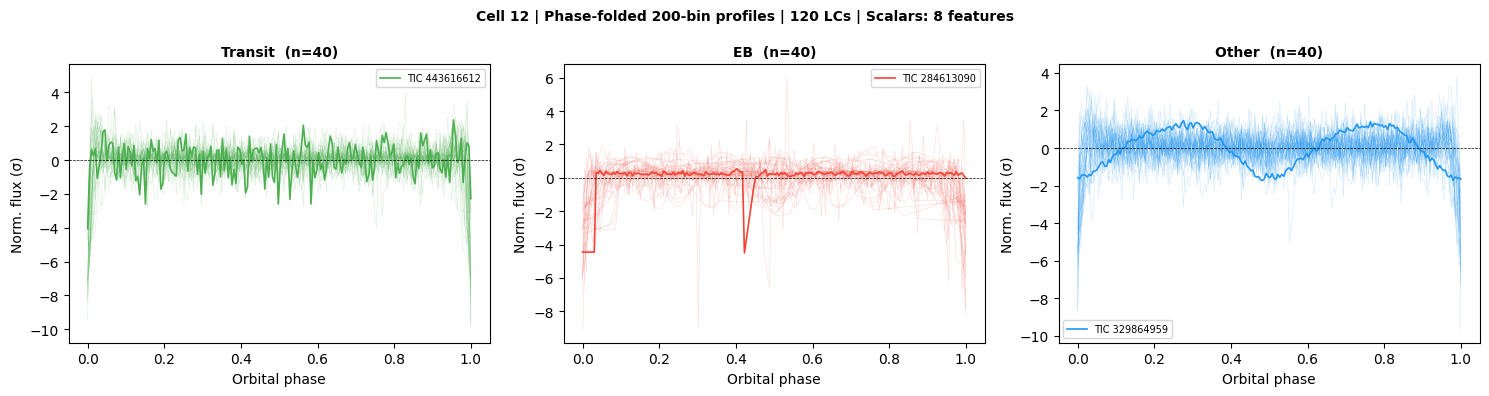

Saved → phase_fold_profiles.png

✓  Cell 12 done. N_SCALAR for NB-02 CONFIG = 8


In [12]:
# ─── Cell 12 — Phase-fold, feature matrix, stratified split ──────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

cleaned_dir = f"{CONFIG['OUTPUT_DIR']}/lightcurves_cleaned"
tls_df      = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/tls_results.csv")
ok          = tls_df[tls_df["status"] == "ok"].copy()

ok["true_depth_ppm"] = ok["depth_ppm"]

print("=== DEPTH VERIFICATION (Transit should be ~3-15k ppm) ===")
print(ok.groupby("label")["true_depth_ppm"]
        .agg(["min","median","max"]).round(1)
        .rename(columns={"min":"min_ppm","median":"median_ppm","max":"max_ppm"}))

N_BINS = 200

def phase_fold_bin(t, flux, period, t0, n_bins=200):
    phase   = ((t - t0) / period) % 1.0
    edges   = np.linspace(0, 1, n_bins + 1)
    binned  = np.full(n_bins, np.nan)
    for i in range(n_bins):
        in_bin = (phase >= edges[i]) & (phase < edges[i + 1])
        if in_bin.sum() >= 2:
            binned[i] = np.median(flux[in_bin])
    nans = np.isnan(binned)
    if nans.sum() < n_bins * 0.5:
        x = np.arange(n_bins)
        binned[nans] = np.interp(x[nans], x[~nans], binned[~nans])
    else:
        binned = np.nan_to_num(binned, nan=0.0)
    std = np.std(binned)
    if std > 1e-9:
        binned = (binned - np.mean(binned)) / std
    return binned

# FLAG-21/23 FIX: added secondary_depth_ppm + has_secondary → 8 scalar features
# NB-02 CONFIG["N_SCALAR"] must be updated to 8 to match.
SCALAR_FEATS = ["sde", "snr", "period", "duration_hr", "n_transits",
                "true_depth_ppm", "secondary_depth_ppm", "has_secondary"]

# Guard: fill missing secondary columns (in case Cell 10 was run on old data)
for col in ["secondary_depth_ppm", "has_secondary"]:
    if col not in ok.columns:
        ok[col] = 0.0
        print(f"⚠  Column '{col}' missing from tls_results — filled with 0. "
              f"Re-run Cell 10 to get proper secondary eclipse features.")

feat_lookup = ok.set_index("tic_id")[SCALAR_FEATS]

print(f"\nPhase-folding {len(ok)} LCs...")
profiles, scalar_rows, label_list, tic_list = [], [], [], []

for _, row in ok.iterrows():
    tic_id = int(row["tic_id"])
    fp     = f"{cleaned_dir}/TIC{tic_id}_clean.csv"
    try:
        df      = pd.read_csv(fp)
        t       = df["time"].values
        flux    = 1.0 + (df["flat_ppt"].values - 1000.0) / 1e3
        mask    = np.isfinite(t) & np.isfinite(flux)
        t, flux = t[mask], flux[mask]

        profile = phase_fold_bin(t, flux, row["period"], row["t0"], N_BINS)
        frow    = feat_lookup.loc[tic_id]
        scalars = [float(frow[f]) if pd.notna(frow[f]) else 0.0 for f in SCALAR_FEATS]

        profiles.append(profile)
        scalar_rows.append(scalars)
        label_list.append(row["label"])
        tic_list.append(tic_id)

    except Exception as e:
        print(f"  Fold error TIC {tic_id}: {e}")

X_profile = np.array(profiles)
X_scalar  = np.array(scalar_rows)
labels    = np.array(label_list)

print(f"Phase-fold done: {len(profiles)} profiles")
print(f"X_profile: {X_profile.shape}  X_scalar: {X_scalar.shape}")
print(f"Scalar features ({len(SCALAR_FEATS)}): {SCALAR_FEATS}")

le = LabelEncoder()
y  = le.fit_transform(labels)
print(f"\nLabel encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Class counts   : {dict(zip(le.classes_, np.bincount(y)))}")

idx_all = np.arange(len(y))
idx_tr, idx_tmp, y_tr, y_tmp = train_test_split(
    idx_all, y, test_size=0.30, stratify=y, random_state=CONFIG["RANDOM_STATE"]
)
idx_val, idx_te, y_val, y_te = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=CONFIG["RANDOM_STATE"]
)

scaler   = StandardScaler()
X_sc_tr  = scaler.fit_transform(X_scalar[idx_tr])
X_sc_val = scaler.transform(X_scalar[idx_val])
X_sc_te  = scaler.transform(X_scalar[idx_te])

X_pr_tr  = X_profile[idx_tr]
X_pr_val = X_profile[idx_val]
X_pr_te  = X_profile[idx_te]

print(f"\n=== SPLIT SUMMARY ===")
for name, idxs, yy in [("Train", idx_tr, y_tr),
                         ("Val",   idx_val, y_val),
                         ("Test",  idx_te,  y_te)]:
    counts = dict(zip(le.classes_, np.bincount(yy, minlength=3)))
    print(f"  {name:5s}: {len(idxs):>3} samples | {counts}")

save_dir = CONFIG["OUTPUT_DIR"]
for name, arr in [
    ("X_profile_train", X_pr_tr),  ("X_profile_val",  X_pr_val), ("X_profile_test", X_pr_te),
    ("X_scalar_train",  X_sc_tr),  ("X_scalar_val",   X_sc_val), ("X_scalar_test",  X_sc_te),
    ("y_train",         y_tr),     ("y_val",           y_val),   ("y_test",         y_te),
    ("label_classes",   le.classes_),
]:
    np.save(f"{save_dir}/{name}.npy", arr)

import pickle
with open(f"{save_dir}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

pd.DataFrame({
    "tic_id": np.array(tic_list)[idx_tr],
    "label":  labels[idx_tr], "split": "train"
}).to_csv(f"{save_dir}/train_ids.csv", index=False)

# ── Profile plots ─────────────────────────────────────────────────────────────
colors = {"Transit": "#4CAF50", "EB": "#F44336", "Other": "#2196F3"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phase_x   = np.linspace(0, 1, N_BINS)

for ax, cls in zip(axes, ["Transit", "EB", "Other"]):
    idxs = [i for i, l in enumerate(labels) if l == cls]
    if not idxs:
        continue
    for i in idxs:
        ax.plot(phase_x, X_profile[i], color=colors[cls], lw=0.3, alpha=0.25)
    ax.plot(phase_x, X_profile[idxs[0]], color=colors[cls], lw=1.2,
            label=f"TIC {tic_list[idxs[0]]}")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_title(f"{cls}  (n={len(idxs)})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Orbital phase")
    ax.set_ylabel("Norm. flux (σ)")
    ax.legend(fontsize=7)

plt.suptitle(
    f"Cell 12 | Phase-folded 200-bin profiles | {len(profiles)} LCs | "
    f"Scalars: {len(SCALAR_FEATS)} features",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{save_dir}/phase_fold_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → phase_fold_profiles.png")
print(f"\n✓  Cell 12 done. N_SCALAR for NB-02 CONFIG = {len(SCALAR_FEATS)}")

In [13]:
# ─── Cell 12b — Regression targets (Task B) ───────────────────────────────────
# Plan requires period / depth / duration as regression outputs alongside
# classification. These come from TLS — already computed, just not saved yet.
# NB-02 uses them for the regression head and the physics-informed loss.

import pickle as _pickle

tls_df  = pd.read_csv(f"{CONFIG['OUTPUT_DIR']}/tls_results.csv")
ok_reg  = tls_df[tls_df["status"] == "ok"].copy()

# Align to the same row order as X_profile / X_scalar (built during phase-folding)
tic_to_idx = {tic: i for i, tic in enumerate(tic_list)}
ok_reg     = ok_reg[ok_reg["tic_id"].isin(tic_to_idx)].copy()
ok_reg["_order"] = ok_reg["tic_id"].map(tic_to_idx)
ok_reg     = ok_reg.sort_values("_order").reset_index(drop=True)

# Regression target columns:
#   col 0 = period (days)
#   col 1 = depth_ppm
#   col 2 = duration_hr
y_reg = ok_reg[["period", "depth_ppm", "duration_hr"]].values.astype(np.float32)
y_reg = np.nan_to_num(y_reg, nan=0.0)   # TLS may return NaN for duration on noisy LCs

print(f"Regression target array: {y_reg.shape}  [period_days, depth_ppm, duration_hr]")
print(f"  period    → min={y_reg[:,0].min():.3f}  max={y_reg[:,0].max():.3f}  days")
print(f"  depth_ppm → min={y_reg[:,1].min():.0f}  max={y_reg[:,1].max():.0f}  ppm")
print(f"  duration  → min={y_reg[:,2].min():.3f}  max={y_reg[:,2].max():.3f}  hrs")

# Split with same indices as Cell 12
y_reg_tr  = y_reg[idx_tr]
y_reg_val = y_reg[idx_val]
y_reg_te  = y_reg[idx_te]

# Fit a scaler so NB-02 can normalise regression targets for stable training
from sklearn.preprocessing import StandardScaler as _SS
reg_scaler = _SS()
reg_scaler.fit(y_reg_tr)

print(f"\nRegression scaler (fitted on train split):")
print(f"  means : period={reg_scaler.mean_[0]:.3f}d  "
      f"depth={reg_scaler.mean_[1]:.0f}ppm  "
      f"dur={reg_scaler.mean_[2]:.3f}hr")
print(f"  stds  : {np.round(reg_scaler.scale_, 2)}")

save_dir = CONFIG["OUTPUT_DIR"]
for name, arr in [
    ("y_reg_train", y_reg_tr),
    ("y_reg_val",   y_reg_val),
    ("y_reg_test",  y_reg_te),
]:
    np.save(f"{save_dir}/{name}.npy", arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

with open(f"{save_dir}/reg_scaler.pkl", "wb") as f:
    _pickle.dump(reg_scaler, f)

print(f"  Saved reg_scaler.pkl")
print(f"\n✓  Regression targets saved. NB-02 N_REG = 3.")

Regression target array: (120, 3)  [period_days, depth_ppm, duration_hr]
  period    → min=0.606  max=14.097  days
  depth_ppm → min=122  max=277839  ppm
  duration  → min=0.051  max=7.377  hrs

Regression scaler (fitted on train split):
  means : period=4.218d  depth=14130ppm  dur=1.997hr
  stds  : [3.440000e+00 2.996231e+04 1.270000e+00]
  Saved y_reg_train.npy  shape=(84, 3)
  Saved y_reg_val.npy  shape=(18, 3)
  Saved y_reg_test.npy  shape=(18, 3)
  Saved reg_scaler.pkl

✓  Regression targets saved. NB-02 N_REG = 3.


=== RANDOM FOREST BASELINE (5-fold stratified CV) ===
Features : ['sde', 'snr', 'period', 'duration_hr', 'n_transits', 'true_depth_ppm', 'secondary_depth_ppm', 'has_secondary']
Samples  : 120  |  Classes: ['EB', 'Other', 'Transit']

5-fold CV macro-F1 (RF baseline): 0.5557
Per-class F1:
        EB: 0.6849
     Other: 0.4938
   Transit: 0.4884

              precision    recall  f1-score   support

          EB      0.758     0.625     0.685        40
       Other      0.488     0.500     0.494        40
     Transit      0.457     0.525     0.488        40

    accuracy                          0.550       120
   macro avg      0.567     0.550     0.556       120
weighted avg      0.567     0.550     0.556       120

Feature importances (train split):
                        snr: 0.1947  █████████
             true_depth_ppm: 0.1790  ████████
                        sde: 0.1493  ███████
                     period: 0.1365  ██████
                duration_hr: 0.1254  ██████
        seco

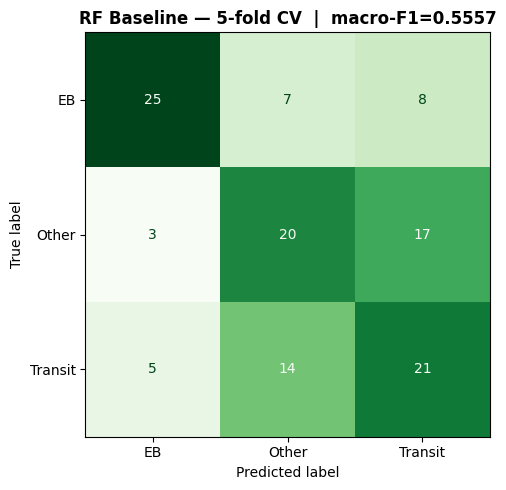

Saved → baseline_rf_cm.png

✓  NB-01 COMPLETE — all arrays ready for NB-02.


In [14]:
# ─── Cell 13 — Classical Baseline: Random Forest ──────────────────────────────
# Plan specifies an RF baseline (NB-01 Cell 19) that NB-02 must beat.
# Uses the same 8 scalar features as NB-02's MLP branch.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import json

print("=== RANDOM FOREST BASELINE (5-fold stratified CV) ===")
print(f"Features : {SCALAR_FEATS}")
print(f"Samples  : {X_scalar.shape[0]}  |  Classes: {le.classes_.tolist()}")

rf = RandomForestClassifier(
    n_estimators = 500,
    max_depth    = None,
    class_weight = "balanced",
    random_state = CONFIG["RANDOM_STATE"],
    n_jobs       = -1,
)

skf_rf   = StratifiedKFold(n_splits=5, shuffle=True,
                            random_state=CONFIG["RANDOM_STATE"])
cv_preds = cross_val_predict(rf, X_scalar, y, cv=skf_rf)

rf_f1     = f1_score(y, cv_preds, average="macro",  zero_division=0)
rf_f1_per = f1_score(y, cv_preds, average=None,     zero_division=0)

print(f"\n5-fold CV macro-F1 (RF baseline): {rf_f1:.4f}")
print("Per-class F1:")
for cls, score in zip(le.classes_, rf_f1_per):
    print(f"  {cls:>8}: {score:.4f}")

print("\n" + classification_report(
    y, cv_preds, target_names=le.classes_.tolist(), digits=3, zero_division=0
))

# Feature importances (fit on full train split)
rf.fit(X_scalar[idx_tr], y_tr)
importances = rf.feature_importances_
print("Feature importances (train split):")
for feat, imp in sorted(zip(SCALAR_FEATS, importances), key=lambda x: -x[1]):
    bar = "█" * int(imp * 50)
    print(f"  {feat:>25}: {imp:.4f}  {bar}")

# Save
rf_results = {
    "cv_macro_f1"  : round(rf_f1, 4),
    "per_class_f1" : dict(zip(le.classes_.tolist(),
                               [round(v, 4) for v in rf_f1_per])),
    "feature_names": SCALAR_FEATS,
    "importances"  : [round(v, 6) for v in importances.tolist()],
}
with open(f"{CONFIG['OUTPUT_DIR']}/baseline_rf_results.json", "w") as f:
    json.dump(rf_results, f, indent=2)
print(f"\nSaved → baseline_rf_results.json")
print(f"\n⚡  NB-02 target: CV macro-F1 > {rf_f1:.4f}  (beat this RF baseline)")

# Confusion matrix
cm_rf = confusion_matrix(y, cv_preds, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"RF Baseline — 5-fold CV  |  macro-F1={rf_f1:.4f}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/baseline_rf_cm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → baseline_rf_cm.png")
print("\n✓  NB-01 COMPLETE — all arrays ready for NB-02.")